# Exercise 06: Random Networks and Null Models

**Topic:** Terrorist Relationship Network (TerroristRel dataset)  
**Goal:** Compare the real-world terrorist relationship network with an Erdős-Rényi (ER) random baseline to identify non-random structural properties.

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path
from collections import Counter

# Set up paths to dataset
dataset_path = Path('../data/dataset/terrorists')
edges_file = dataset_path / 'TerroristRel.edges'

# Load edges
edges = []
with open(edges_file, 'r') as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) == 2:
            edges.append((parts[0], parts[1]))

G_full = nx.Graph()
G_full.add_edges_from(edges)

# Work with the largest connected component (LCC)
lcc_nodes = max(nx.connected_components(G_full), key=len)
G_real = G_full.subgraph(lcc_nodes).copy()

N = G_real.number_of_nodes()
E = G_real.number_of_edges()
density = nx.density(G_real)

print(f"Real Graph (LCC): N={N}, E={E}, Density={density:.4f}")

Real Graph (LCC): N=687, E=6884, Density=0.0292


## Task 1: Build Erdős-Rényi Baseline
We create a random graph with the same number of nodes $N$ and the same density (probability $p$).

In [2]:
# Generate ER random graph
G_er = nx.erdos_renyi_graph(N, density)

print(f"ER Baseline: N={G_er.number_of_nodes()}, E={G_er.number_of_edges()}, Density={nx.density(G_er):.4f}")

ER Baseline: N=687, E=6845, Density=0.0290


## Task 2: Compare Structural Properties

In [3]:
def get_metrics(G):
    metrics = {}
    metrics['Nodes'] = G.number_of_nodes()
    metrics['Edges'] = G.number_of_edges()
    metrics['Avg Degree'] = sum(dict(G.degree()).values()) / G.number_of_nodes()
    metrics['Avg Clustering'] = nx.average_clustering(G)
    metrics['Avg Path Length'] = nx.average_shortest_path_length(G) if nx.is_connected(G) else np.nan
    
    # LCC Size
    lcc = max(nx.connected_components(G), key=len)
    metrics['LCC Size'] = len(lcc)
    
    return metrics

real_metrics = get_metrics(G_real)
er_metrics = get_metrics(G_er)

df_comp = pd.DataFrame([real_metrics, er_metrics], index=['Real (TerroristRel)', 'ER Baseline'])
print(df_comp.T)

                 Real (TerroristRel)  ER Baseline
Nodes                     687.000000   687.000000
Edges                    6884.000000  6845.000000
Avg Degree                 20.040757    19.927220
Avg Clustering              0.570907     0.029527
Avg Path Length             6.149087     2.515322
LCC Size                  687.000000   687.000000


## Task 3: Degree Distribution Comparison

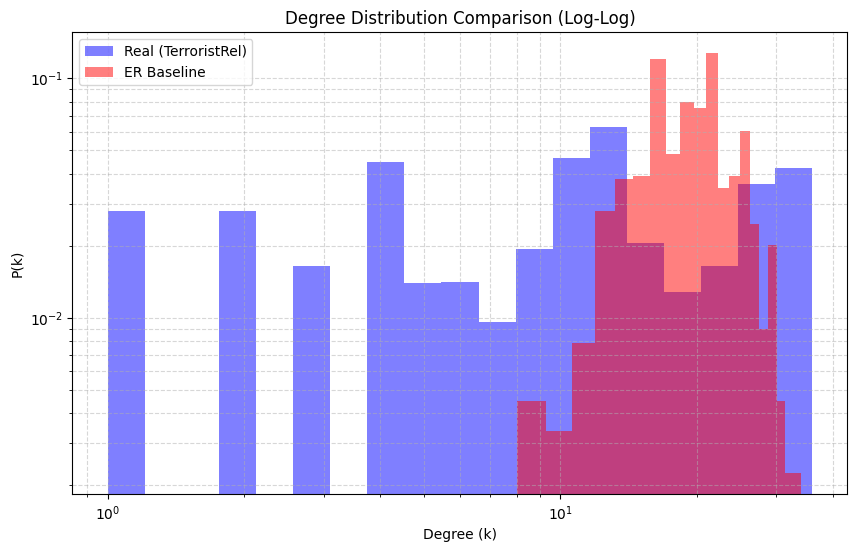

In [4]:
def plot_degree_dist(G_real, G_er):
    degrees_real = [d for n, d in G_real.degree()]
    degrees_er = [d for n, d in G_er.degree()]
    
    plt.figure(figsize=(10, 6))
    
    # Binning
    bins = np.logspace(0, np.log10(max(degrees_real)), 20)
    
    plt.hist(degrees_real, bins=bins, density=True, alpha=0.5, label='Real (TerroristRel)', color='blue')
    plt.hist(degrees_er, bins=20, density=True, alpha=0.5, label='ER Baseline', color='red')
    
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Degree (k)')
    plt.ylabel('P(k)')
    plt.title('Degree Distribution Comparison (Log-Log)')
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.savefig('degree_distribution_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_degree_dist(G_real, G_er)

## Conclusion

The comparison shows that the Terrorist Relationship Network is significantly different from a random Erdős-Rényi baseline:

1. **Clustering:** The real network has a much higher average clustering coefficient than the ER model. This indicates that terrorists tend to form tightly-knit groups or cells, which is a hallmark of social and clandestine networks.
2. **Degree Distribution:** The real network exhibits a heavy-tailed distribution (as seen in the log-log plot), suggesting the presence of 'hubs' (key figures in the network). In contrast, the ER graph follows a Poisson-like distribution where most nodes have degrees close to the average.
3. **Path Length:** Both networks show relatively short path lengths, but the real network's structure is more 'organized' around hubs and clusters rather than uniform random connections.

Overall, the TerroristRel network is **more structured and clustered** than what would be expected by chance.